In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("chip_dataset.csv")
df.tail()

,Unnamed: 0,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
4849,4849,NVIDIA Quadro 3000M,GPU,2011-02-22,40.0,75.0,332.0,1950.0,450.0,TSMC,NVIDIA,NaN,432.0,36.0
4850,4850,Intel GMA 950,GPU,2005-06-01,90.0,7.0,NaN,NaN,250.0,Intel,Intel,NaN,NaN,NaN
4851,4851,NVIDIA GeForce GT 320M,GPU,2010-03-03,40.0,23.0,100.0,486.0,500.0,TSMC,NVIDIA,NaN,52.8,NaN
4852,4852,NVIDIA GeForce FX 5200,GPU,2003-03-06,150.0,NaN,65.0,29.0,250.0,TSMC,NVIDIA,NaN,NaN,NaN
4853,4853,NVIDIA GeForce 9300 SE,GPU,2008-06-01,65.0,NaN,86.0,210.0,540.0,TSMC,NVIDIA,NaN,20.8,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             4854 non-null   int64  
 1   Product                4854 non-null   str    
 2   Type                   4854 non-null   str    
 3   Release Date           4854 non-null   str    
 4   Process Size (nm)      4845 non-null   float64
 5   TDP (W)                4228 non-null   float64
 6   Die Size (mm^2)        4139 non-null   float64
 7   Transistors (million)  4143 non-null   float64
 8   Freq (MHz)             4854 non-null   float64
 9   Foundry                4854 non-null   str    
 10  Vendor                 4854 non-null   str    
 11  FP16 GFLOPS            536 non-null    float64
 12  FP32 GFLOPS            1948 non-null   float64
 13  FP64 GFLOPS            1306 non-null   float64
dtypes: float64(8), int64(1), str(5)
memory usage: 531.0 KB


In [4]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns
print(categorical_columns)

Index(['Product', 'Type', 'Release Date', 'Foundry', 'Vendor'], dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_16856\1665102892.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [5]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns
print(numerical_columns)

Index(['Unnamed: 0', 'Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
       'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS',
       'FP64 GFLOPS'],
      dtype='str')


missing columns

In [6]:
df[numerical_columns].isnull().sum()

Unnamed: 0                  0
Process Size (nm)           9
TDP (W)                   626
Die Size (mm^2)           715
Transistors (million)     711
Freq (MHz)                  0
FP16 GFLOPS              4318
FP32 GFLOPS              2906
FP64 GFLOPS              3548
dtype: int64

In [7]:
# Drop the unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4854 non-null   str    
 1   Type                   4854 non-null   str    
 2   Release Date           4854 non-null   str    
 3   Process Size (nm)      4845 non-null   float64
 4   TDP (W)                4228 non-null   float64
 5   Die Size (mm^2)        4139 non-null   float64
 6   Transistors (million)  4143 non-null   float64
 7   Freq (MHz)             4854 non-null   float64
 8   Foundry                4854 non-null   str    
 9   Vendor                 4854 non-null   str    
 10  FP16 GFLOPS            536 non-null    float64
 11  FP32 GFLOPS            1948 non-null   float64
 12  FP64 GFLOPS            1306 non-null   float64
dtypes: float64(8), str(5)
memory usage: 493.1 KB


In [9]:
df.describe(include="all")

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
count,4854,4854,4854,4845.000000,4228.000000,4139.000000,4143.000000,4854.000000,4854,4854,536.000000,1948.000000,1306.000000
unique,4278,2,1357,NaN,NaN,NaN,NaN,NaN,10,5,NaN,NaN,NaN
top,AMD Athlon 64 3200+,GPU,NaT,NaN,NaN,NaN,NaN,NaN,TSMC,AMD,NaN,NaN,NaN
freq,12,2662,75,NaN,NaN,NaN,NaN,NaN,2178,1662,NaN,NaN,NaN
mean,NaN,NaN,NaN,55.109598,81.359981,188.440445,1929.922279,1484.406057,NaN,NaN,8397.459851,2134.756653,363.670511
std,NaN,NaN,NaN,44.998676,76.807808,126.189383,4044.891098,1066.701523,NaN,NaN,13799.551131,3898.431487,1145.931856
min,NaN,NaN,NaN,0.000000,1.000000,1.000000,8.000000,100.000000,NaN,NaN,10.020000,12.800000,3.600000
25%,NaN,NaN,NaN,22.000000,33.000000,104.000000,154.000000,590.000000,NaN,NaN,768.800000,257.300000,38.295000
50%,NaN,NaN,NaN,40.000000,65.000000,148.000000,624.000000,1073.500000,NaN,NaN,2965.500000,696.000000,89.280000
75%,NaN,NaN,NaN,90.000000,100.000000,239.000000,1550.000000,2400.000000,NaN,NaN,10600.000000,2116.750000,220.000000


In [10]:
df.duplicated().sum()

np.int64(110)

In [11]:
df = df.drop_duplicates()

In [12]:
df["Release Date"] = pd.to_datetime(
    df["Release Date"],
    errors="coerce")

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 4744 entries, 0 to 4853
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Product                4744 non-null   str           
 1   Type                   4744 non-null   str           
 2   Release Date           4669 non-null   datetime64[us]
 3   Process Size (nm)      4735 non-null   float64       
 4   TDP (W)                4144 non-null   float64       
 5   Die Size (mm^2)        4056 non-null   float64       
 6   Transistors (million)  4050 non-null   float64       
 7   Freq (MHz)             4744 non-null   float64       
 8   Foundry                4744 non-null   str           
 9   Vendor                 4744 non-null   str           
 10  FP16 GFLOPS            531 non-null    float64       
 11  FP32 GFLOPS            1928 non-null   float64       
 12  FP64 GFLOPS            1291 non-null   float64       
dtypes: datetime64[us](1

In [14]:
df.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN


In [15]:
df["Release Year"] = df["Release Date"].dt.year
df["Release Month"] = df["Release Date"].dt.month
df["Release Quarter"] = df["Release Date"].dt.quarter


print(
    df[
        [
            "Release Date",
            "Release Year",
            "Release Month",
            "Release Quarter"
        ]
    ].head()
)

  Release Date  Release Year  Release Month  Release Quarter
0   2007-02-20        2007.0            2.0              1.0
1   2018-09-06        2018.0            9.0              3.0
2   2020-09-02        2020.0            9.0              3.0
3   2013-09-01        2013.0            9.0              3.0
4   2011-05-03        2011.0            5.0              2.0


In [16]:
# check numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print(numerical_columns)

Index(['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
       'Transistors (million)', 'Freq (MHz)', 'FP16 GFLOPS', 'FP32 GFLOPS',
       'FP64 GFLOPS', 'Release Year', 'Release Month', 'Release Quarter'],
      dtype='str')


In [17]:
columns_to_impute = [
    "Process Size (nm)",
    "TDP (W)",
    "Die Size (mm^2)",
    "Transistors (million)"
]

for column in columns_to_impute:

    # Create missing-value indicator
    df[column + "_Missing"] = df[column].isnull().astype(int)

    # Median based on chip type
    df[column] = df.groupby("Type")[column].transform(
        lambda x: x.fillna(x.median())
    )


print(
    df[columns_to_impute]
    .isnull()
    .sum()
)

Process Size (nm)        0
TDP (W)                  0
Die Size (mm^2)          0
Transistors (million)    0
dtype: int64


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 4744 entries, 0 to 4853
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Product                        4744 non-null   str           
 1   Type                           4744 non-null   str           
 2   Release Date                   4669 non-null   datetime64[us]
 3   Process Size (nm)              4744 non-null   float64       
 4   TDP (W)                        4744 non-null   float64       
 5   Die Size (mm^2)                4744 non-null   float64       
 6   Transistors (million)          4744 non-null   float64       
 7   Freq (MHz)                     4744 non-null   float64       
 8   Foundry                        4744 non-null   str           
 9   Vendor                         4744 non-null   str           
 10  FP16 GFLOPS                    531 non-null    float64       
 11  FP32 GFLOPS                    19

In [19]:
performance_columns = [
    "FP16 GFLOPS",
    "FP32 GFLOPS",
    "FP64 GFLOPS"
]



for column in performance_columns:

    print(column)

    print(
        df.groupby("Type")[column]
        .apply(lambda x: x.isnull().sum())
    )

FP16 GFLOPS
Type
CPU    2132
GPU    2081
Name: FP16 GFLOPS, dtype: int64
FP32 GFLOPS
Type
CPU    2132
GPU     684
Name: FP32 GFLOPS, dtype: int64
FP64 GFLOPS
Type
CPU    2132
GPU    1321
Name: FP64 GFLOPS, dtype: int64


GFLOPS variables missing is largely structural. CPU records do not have GPU-specific GFLOPS measurements, and some older chips do not have all performance metrics available. 
Trying to imput these values could distort the analysis

## EDA

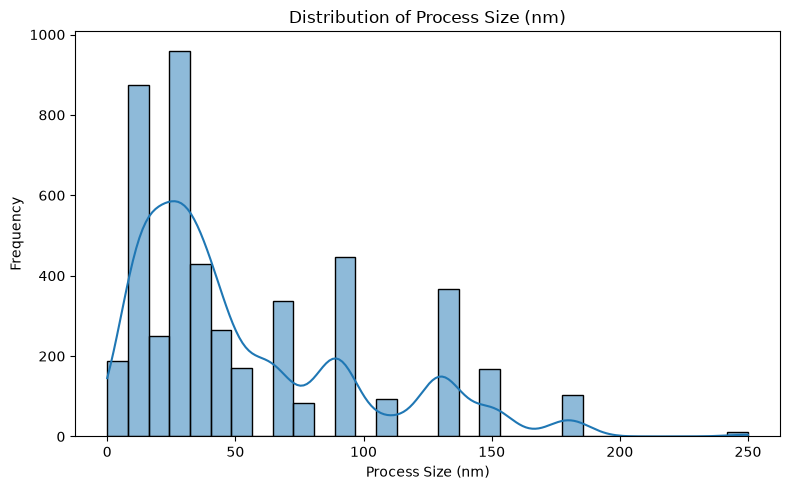

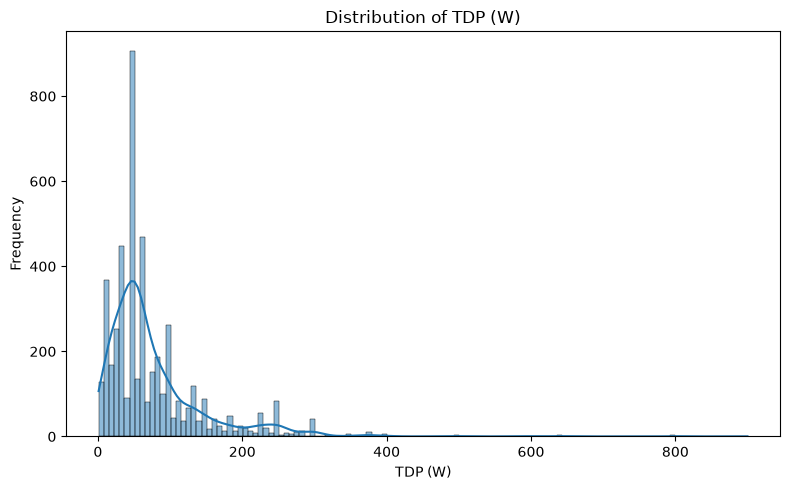

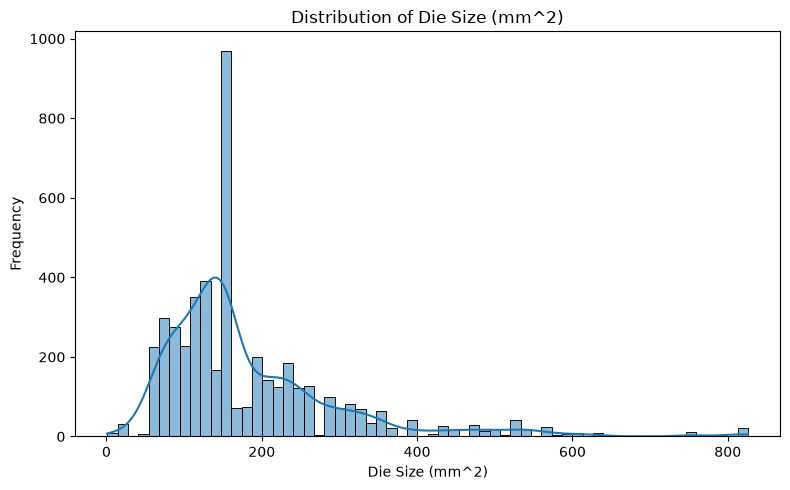

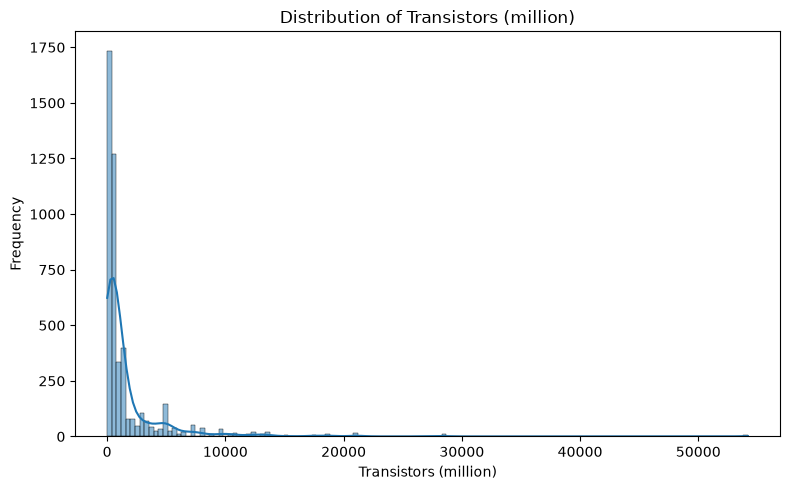

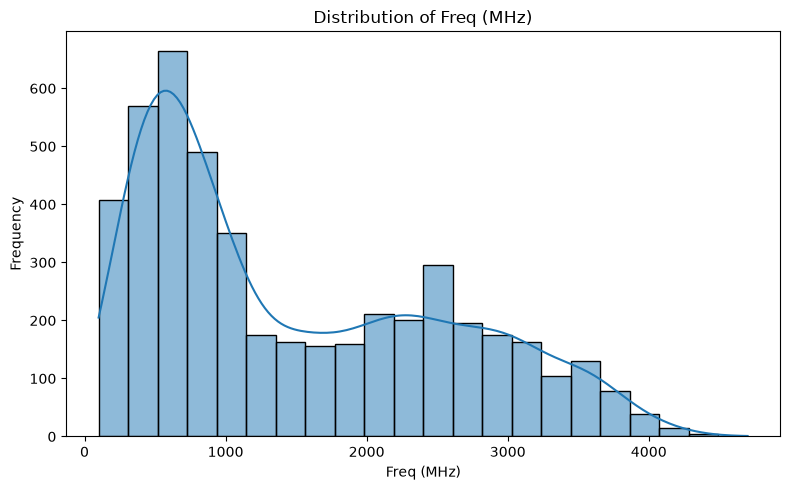

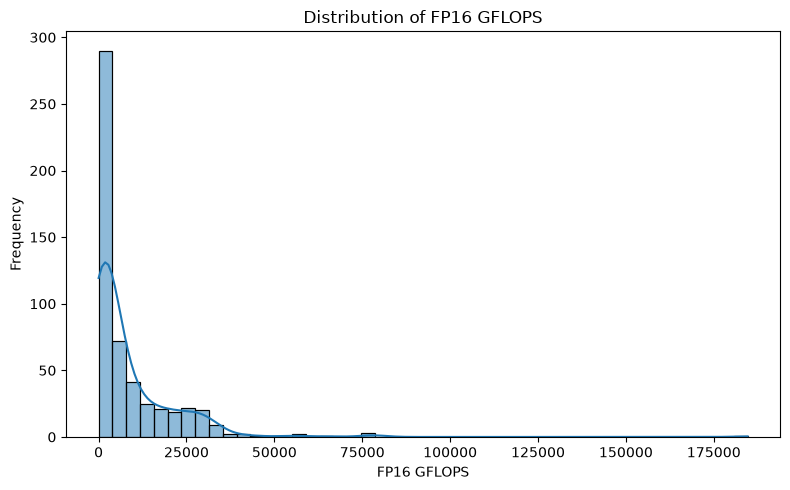

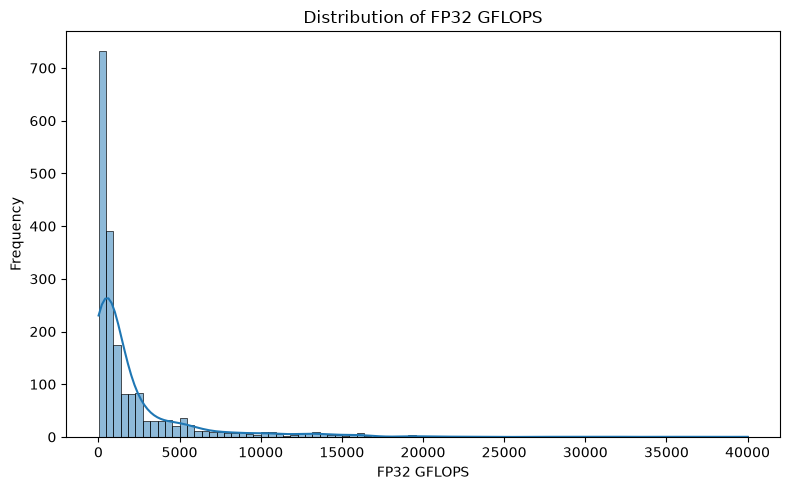

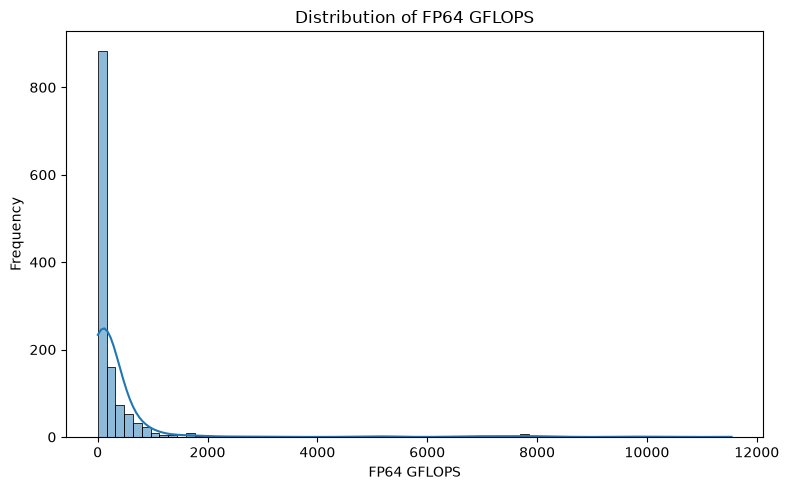

In [20]:
numeric_cols = [
    "Process Size (nm)",
    "TDP (W)",
    "Die Size (mm^2)",
    "Transistors (million)",
    "Freq (MHz)",
    "FP16 GFLOPS",
    "FP32 GFLOPS",
    "FP64 GFLOPS"
]

for column in numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[column].dropna(),
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(
        f"distribution_{column.replace(' ', '_')}.png"
    )

    plt.show()

In [21]:
frequency_summary = df.groupby("Type")["Freq (MHz)"].agg(
    ["mean", "median", "max"]
)

print(frequency_summary)

             mean  median     max
Type                             
CPU   2486.001407  2400.0  4700.0
GPU    666.276417   606.0  2321.0


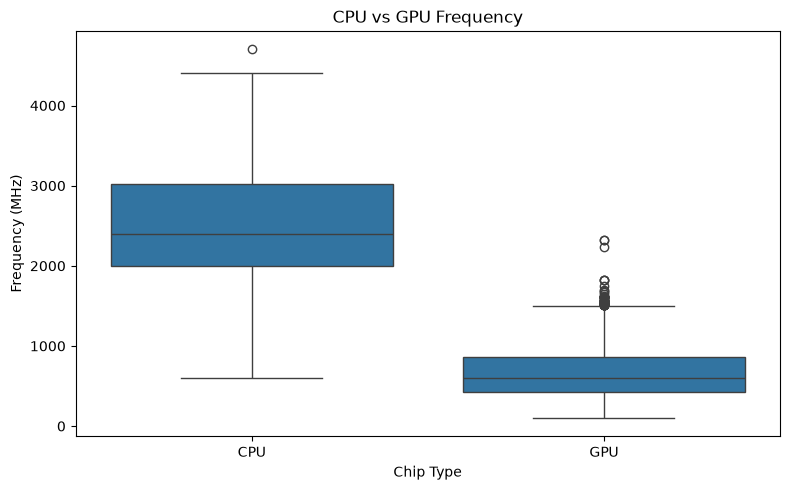

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Type",
    y="Freq (MHz)"
)

plt.title("CPU vs GPU Frequency")
plt.xlabel("Chip Type")
plt.ylabel("Frequency (MHz)")

plt.tight_layout()
plt.savefig("cpu_vs_gpu_frequency.png")
plt.show()

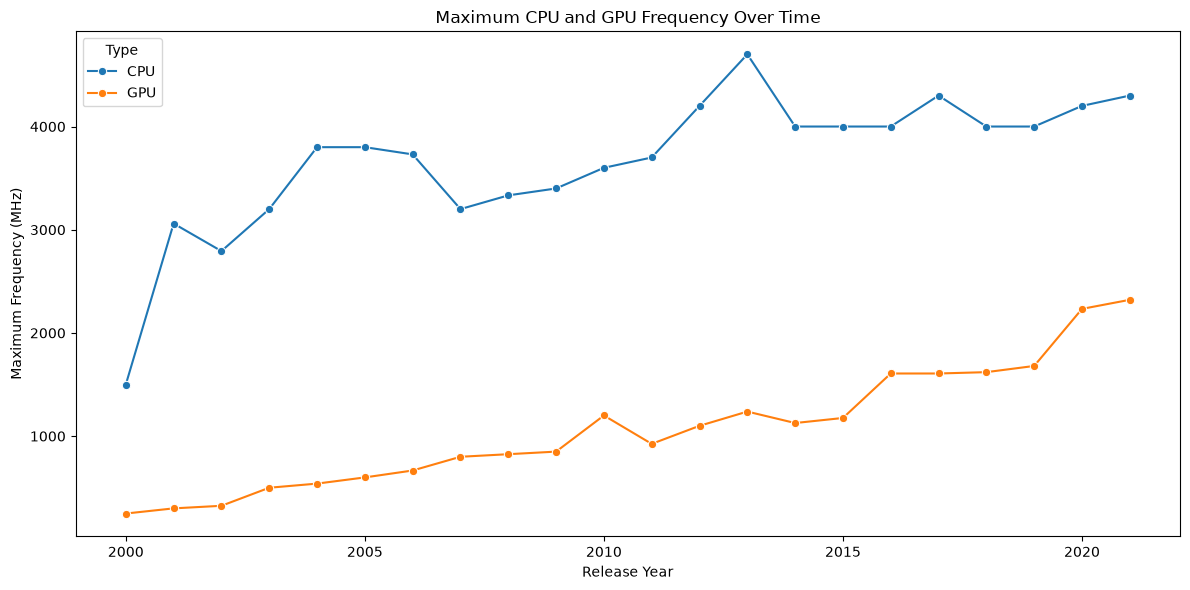

In [23]:
frequency_year = (
    df.groupby(["Release Year", "Type"])["Freq (MHz)"]
    .max()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=frequency_year,
    x="Release Year",
    y="Freq (MHz)",
    hue="Type",
    marker="o"
)

plt.title("Maximum CPU and GPU Frequency Over Time")
plt.xlabel("Release Year")
plt.ylabel("Maximum Frequency (MHz)")

plt.tight_layout()
plt.savefig("frequency_over_time.png")
plt.show()

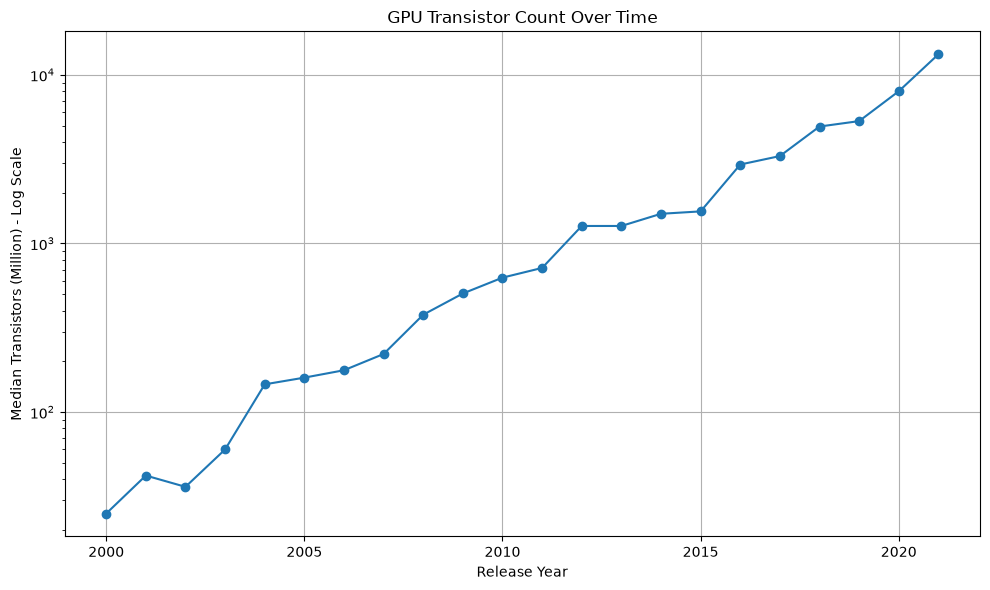

In [24]:
gpu = df[df["Type"] == "GPU"].copy()

gpu_transistors = (
    gpu.groupby("Release Year")["Transistors (million)"]
    .median()
    .dropna()
)

plt.figure(figsize=(10, 6))

plt.plot(
    gpu_transistors.index,
    gpu_transistors.values,
    marker="o"
)

plt.yscale("log")

plt.title("GPU Transistor Count Over Time")
plt.xlabel("Release Year")
plt.ylabel("Median Transistors (Million) - Log Scale")

plt.grid(True)
plt.tight_layout()

plt.savefig("moores_law_gpu.png")
plt.show()

In [26]:
from scipy.stats import linregress

In [28]:
x = gpu_transistors.index.values
y = np.log2(gpu_transistors.values)

slope, intercept, r_value, p_value, std_err = linregress(x, y)

doubling_time = 1 / slope
r_squared = r_value ** 2

# Moore's Law is the observation that the number of transistors on a microchip doubles roughly every two years, 
# while the cost of computers is halved

print("R²:", r_squared)
print("Estimated transistor doubling time:",
      doubling_time, "years")

R²: 0.9866375784772764
Estimated transistor doubling time: 2.469902876839559 years


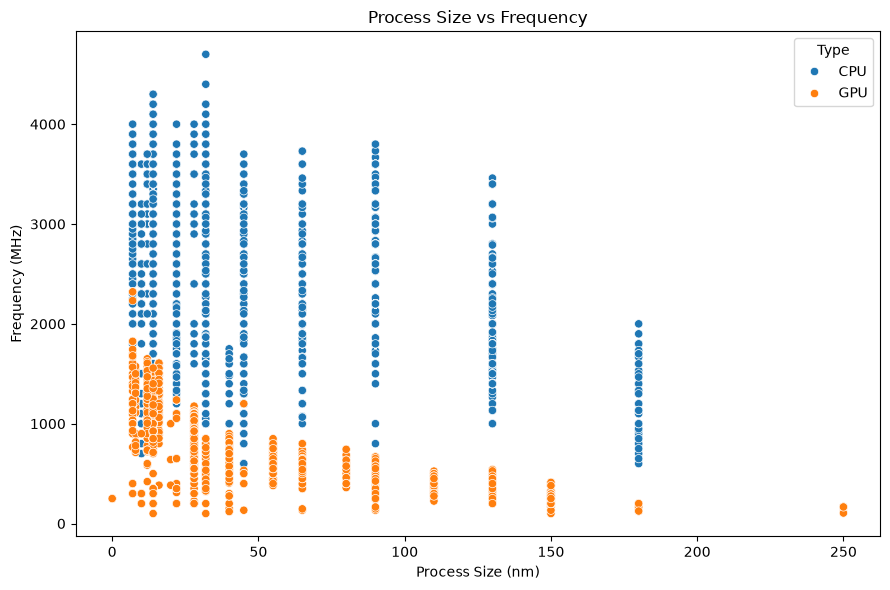

In [29]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Process Size (nm)",
    y="Freq (MHz)",
    hue="Type"
)

plt.title(
    "Process Size vs Frequency"
)

plt.xlabel("Process Size (nm)")
plt.ylabel("Frequency (MHz)")

plt.tight_layout()
plt.savefig("process_size_vs_frequency.png")
plt.show()

In [30]:
# correlation
print(
    df[
        ["Process Size (nm)", "Freq (MHz)"]
    ].corr()
)

                   Process Size (nm)  Freq (MHz)
Process Size (nm)           1.000000   -0.281054
Freq (MHz)                 -0.281054    1.000000


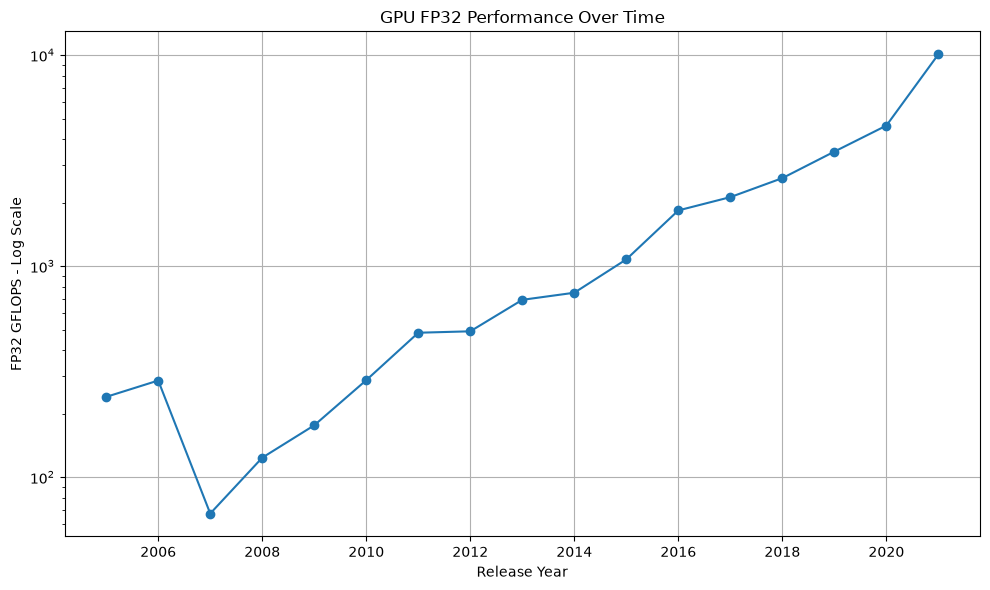

In [31]:
# GPU performance
gpu_fp32 = (
    gpu.dropna(subset=["FP32 GFLOPS"])
    .groupby("Release Year")["FP32 GFLOPS"]
    .median()
)

plt.figure(figsize=(10, 6))

plt.plot(
    gpu_fp32.index,
    gpu_fp32.values,
    marker="o"
)

plt.yscale("log")

plt.title("GPU FP32 Performance Over Time")
plt.xlabel("Release Year")
plt.ylabel("FP32 GFLOPS - Log Scale")

plt.grid(True)

plt.tight_layout()
plt.savefig("gpu_performance_over_time.png")
plt.show()

In [32]:
x = gpu_fp32.index.values
y = np.log2(gpu_fp32.values)

slope, intercept, r_value, p_value, std_err = linregress(
    x,
    y
)

performance_doubling_time = 1 / slope



print(
    "FP32 performance doubling time:",
    performance_doubling_time,
    "years"
)

print(
    "R²:",
    r_value ** 2
)

FP32 performance doubling time: 2.6714894145527652 years
R²: 0.8950950656390047


In [33]:
if performance_doubling_time <= 1.5:
    print(
        "The data support the assumption "
        "that GPU performance doubles every 1.5 years."
    )
else:
    print(
        "The data do NOT support the assumption "
        "that GPU performance doubles every 1.5 years."
    )

The data do NOT support the assumption that GPU performance doubles every 1.5 years.


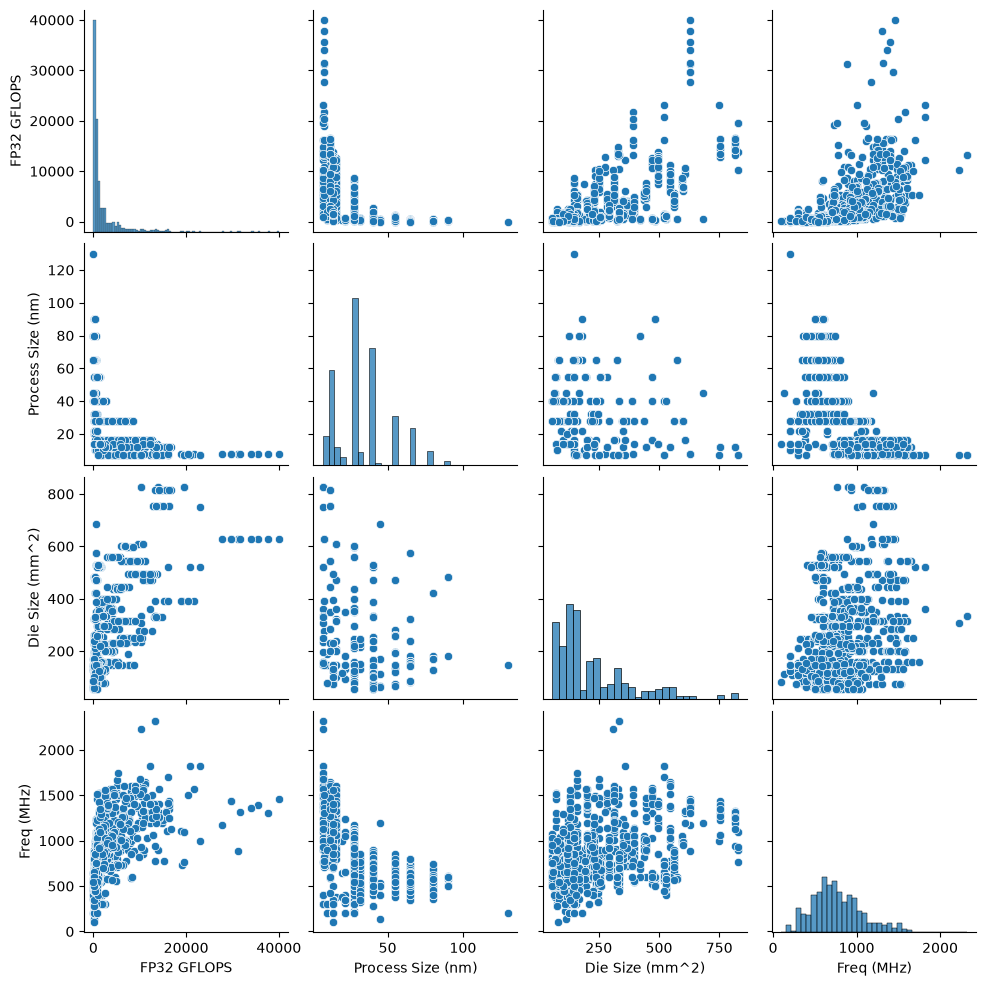

In [ ]:
# gpu performance drivers
gpu_analysis = gpu[
    [
        "FP32 GFLOPS",
        "Process Size (nm)",
        "Die Size (mm^2)",
        "Freq (MHz)"
    ]
].dropna()

sns.pairplot(
    gpu_analysis
)

plt.savefig("gpu_performance_relationships.png")
plt.show()

In [35]:
print(
    gpu_analysis.corr()
)

                   FP32 GFLOPS  Process Size (nm)  Die Size (mm^2)  Freq (MHz)
FP32 GFLOPS           1.000000          -0.467352         0.651455    0.583382
Process Size (nm)    -0.467352           1.000000        -0.167730   -0.488346
Die Size (mm^2)       0.651455          -0.167730         1.000000    0.309342
Freq (MHz)            0.583382          -0.488346         0.309342    1.000000


In [36]:
gpu_high_end = gpu.dropna(
    subset=["FP32 GFLOPS"]
).copy()

threshold = gpu_high_end["FP32 GFLOPS"].quantile(0.90)

gpu_high_end["High_End"] = np.where(
    gpu_high_end["FP32 GFLOPS"] >= threshold,
    "High-End",
    "Other"
)



print(
    gpu_high_end.groupby("High_End")[
        "Process Size (nm)"
    ].describe()
)

           count       mean        std  min   25%   50%   75%    max
High_End                                                            
High-End   193.0  12.621762   5.346040  7.0   8.0  12.0  14.0   28.0
Other     1735.0  35.653602  17.520606  7.0  28.0  28.0  40.0  130.0


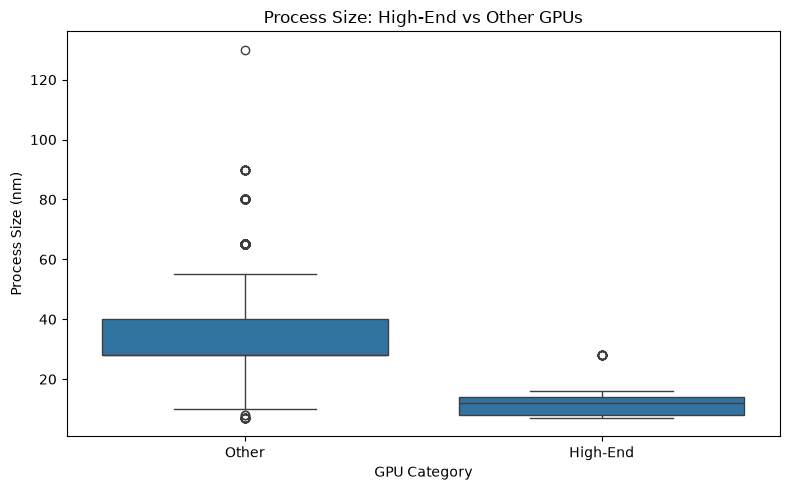

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=gpu_high_end,
    x="High_End",
    y="Process Size (nm)"
)

plt.title(
    "Process Size: High-End vs Other GPUs"
)

plt.xlabel("GPU Category")
plt.ylabel("Process Size (nm)")

plt.tight_layout()

plt.savefig("high_end_gpu_process_size.png")
plt.show()

In [38]:
vendor_process = (
    df.groupby("Vendor")["Process Size (nm)"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .sort_values("median")
)



print(vendor_process)

        count        mean  median   min    max
Vendor                                        
Intel    1343   41.045421    22.0  10.0  180.0
AMD      1638   47.455433    32.0   7.0  180.0
NVIDIA   1178   57.270798    40.0   7.0  250.0
ATI       527   93.975332    90.0  40.0  180.0
Other      58  147.965517   150.0   0.0  250.0


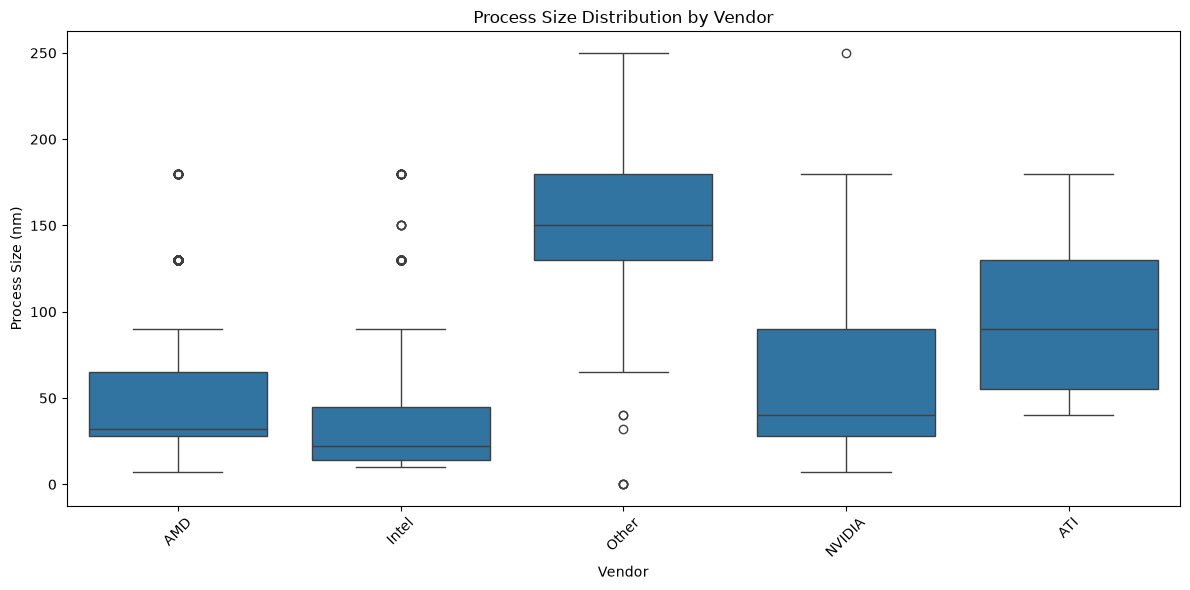

In [39]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Vendor",
    y="Process Size (nm)"
)

plt.title(
    "Process Size Distribution by Vendor"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("process_size_by_vendor.png")
plt.show()

In [40]:
vendors = [
    "Intel",
    "AMD",
    "Nvidia",
    "ATI"
]

print(
    df[df["Vendor"].isin(vendors)]
    .groupby("Vendor")["Process Size (nm)"]
    .median()
    .sort_values()
)

Vendor
Intel    22.0
AMD      32.0
ATI      90.0
Name: Process Size (nm), dtype: float64


In [41]:
# TSMC assumption

foundry_counts = df["Foundry"].value_counts()

print(foundry_counts)

Foundry
TSMC       2156
Intel      1341
Unknown     838
GF          264
UMC          70
Samsung      59
Sony         10
IBM           3
NEC           2
Renesas       1
Name: count, dtype: int64


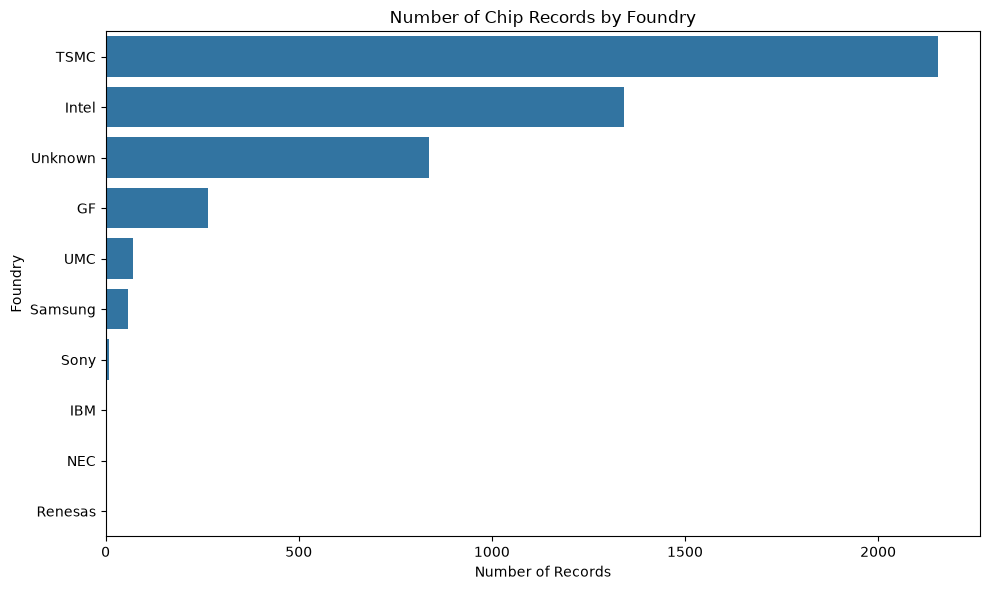

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=foundry_counts.values,
    y=foundry_counts.index
)

plt.title(
    "Number of Chip Records by Foundry"
)

plt.xlabel("Number of Records")
plt.ylabel("Foundry")

plt.tight_layout()

plt.savefig("foundry_counts.png")
plt.show()

In [43]:
print(
    "Most frequently recorded foundry:",
    foundry_counts.index[0]
)

print(
    "Number of records:",
    foundry_counts.iloc[0]
)

Most frequently recorded foundry: TSMC
Number of records: 2156


In [44]:
numeric_data = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_data.corr()


print(correlation_matrix)

                               Process Size (nm)   TDP (W)  Die Size (mm^2)  \
Process Size (nm)                       1.000000 -0.189524        -0.192721   
TDP (W)                                -0.189524  1.000000         0.622526   
Die Size (mm^2)                        -0.192721  0.622526         1.000000   
Transistors (million)                  -0.341908  0.462163         0.636473   
Freq (MHz)                             -0.281054  0.140354        -0.015742   
FP16 GFLOPS                            -0.369721  0.648442         0.698841   
FP32 GFLOPS                            -0.467352  0.516629         0.651455   
FP64 GFLOPS                            -0.216600  0.399429         0.560948   
Release Year                           -0.892363  0.208643         0.202874   
Release Month                           0.003192  0.068521         0.091472   
Release Quarter                        -0.008488  0.069145         0.087864   
Process Size (nm)_Missing              -0.014115  0.

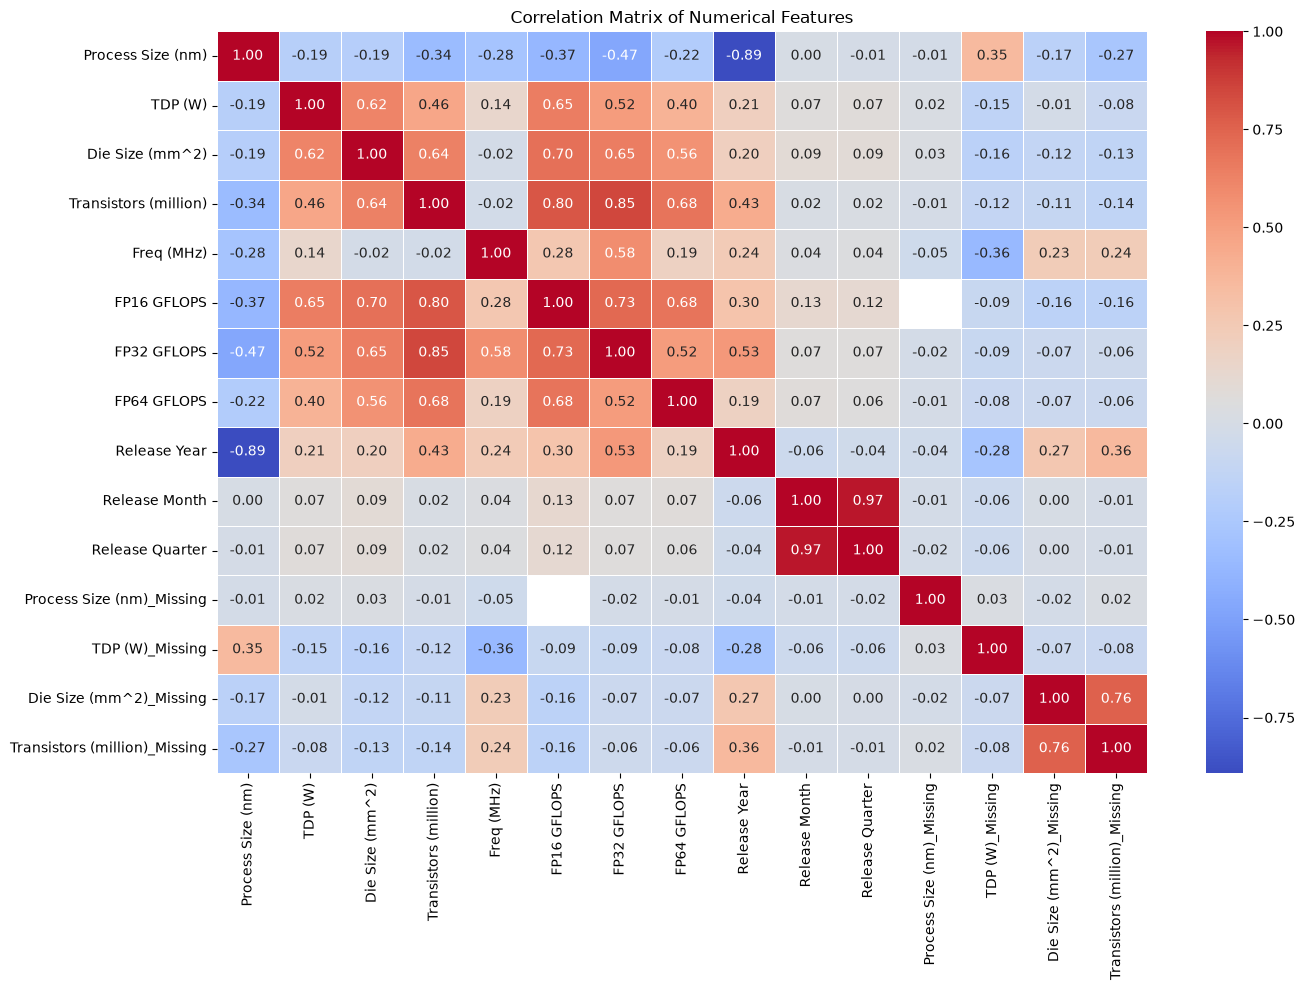

In [45]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.tight_layout()

plt.savefig(
    "correlation_matrix.png",
    dpi=300
)

plt.show()

In [47]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Product', 'Type', 'Foundry', 'Vendor'], dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_16856\3843573000.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [48]:
model_df = df.drop(
    columns=["Product"],
    errors="ignore"
)

In [49]:
categorical_features = [
    "Type",
    "Foundry",
    "Vendor"
]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [50]:


print(model_df.head())

print("New shape:")
print(model_df.shape)

print("Data types:")
print(model_df.dtypes)

  Release Date  Process Size (nm)  TDP (W)  Die Size (mm^2)  \
0   2007-02-20               65.0     45.0             77.0   
1   2018-09-06               14.0     35.0            192.0   
2   2020-09-02               10.0     28.0            150.0   
3   2013-09-01               22.0     80.0            160.0   
4   2011-05-03               45.0    125.0            258.0   

   Transistors (million)  Freq (MHz)  FP16 GFLOPS  FP32 GFLOPS  FP64 GFLOPS  \
0                  122.0      2200.0          NaN          NaN          NaN   
1                 4800.0      3200.0          NaN          NaN          NaN   
2                  410.0      2600.0          NaN          NaN          NaN   
3                 1400.0      1800.0          NaN          NaN          NaN   
4                  758.0      3700.0          NaN          NaN          NaN   

   Release Year  ...  Foundry_Renesas  Foundry_Samsung  Foundry_Sony  \
0        2007.0  ...                0                0             0   
1 

In [51]:
# cleaned dataset
df.to_csv(
    "chip_dataset_cleaned.csv",
    index=False
)

# Save model-ready dataset
model_df.to_csv(
    "chip_dataset_model_ready.csv",
    index=False
)

